# **Project 7: Gibbs Sampling**
Taha Akhlaq & Kenneth Chan

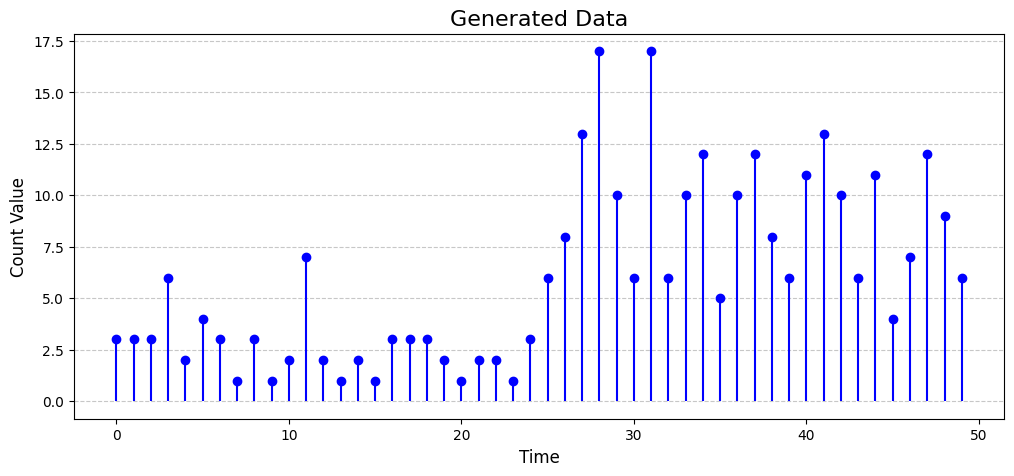

Output()

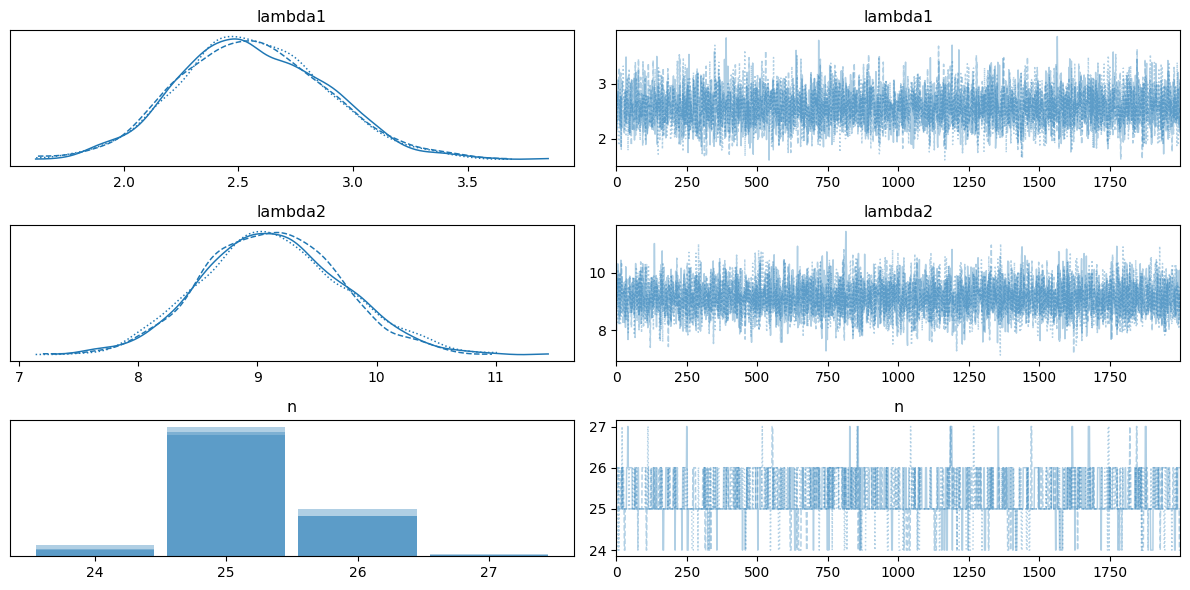

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
np.random.seed(388)

# Define the properties of our fake data
N = 50
true_change_point = 26       # The change happens at the 26th data point
rate_before_change = 3       # The average count before the change
rate_after_change = 9        # The average count after the change

# Empty array to hold data
data = np.zeros(N)

# Fill data (before the change point) using Poisson
data[:true_change_point] = np.random.poisson(rate_before_change, size=true_change_point)

# Fill data (after the change point) using Poisson
data[true_change_point:] = np.random.poisson(rate_after_change, size=N - true_change_point)

# PLOTTING TIME
plt.figure(figsize=(12, 5))
plt.stem(np.arange(N), data, basefmt=" ", linefmt='b-', markerfmt='bo')
plt.title("Generated Data", fontsize=16)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# A model is a set of rules and guesses about how our data was created.
with pm.Model() as change_point_model:

    # lambda1 and lambda2 are the priors.
    lambda1 = pm.Gamma("lambda1", alpha=2.0, beta=1.0)
    lambda2 = pm.Gamma("lambda2", alpha=2.0, beta=1.0)

    # Discrete Uniform Dist.
    n = pm.DiscreteUniform("n", lower=0, upper=N)

    time_index = np.arange(N)
    current_rate = pm.math.switch(time_index < n, lambda1, lambda2)

    Y_obs = pm.Poisson("Y_obs", mu=current_rate, observed=data)

    # Runs the sampler, which is the engine that finds the best values
    # for our priors and n
    trace = pm.sample(2000, tune=1000, chains=3)

# Plotting
az.plot_trace(trace, var_names=["lambda1", "lambda2", "n"])
plt.tight_layout()
plt.show()